# 06 — V-JEPA 2 feature geometry on the training set (PCA + t-SNE)

**Goal.** Visualise how well the SSv2-finetuned V-JEPA 2 backbone
(`facebook/vjepa2-vitl-fpc16-256-ssv2`) separates our 32 challenge
classes *before* we train anything of our own. This sets a ceiling on
what any linear/MLP probe on top of the frozen backbone can hope to
do, and gives us a visual sanity check for the open-world track.

**Pipeline.**
1. For each of the 32 training classes, sample $N$ videos and run them
   through the V-JEPA 2 encoder + attentive pooler. We store the
   *pre-classifier* 1024-d vector (the same input the 174-way SSv2 head
   sees), which already encodes the action prior learned on SSv2.
2. Cache `(features, labels, class_names)` to `vjepa2_train_features.npz`.
3. Repeat 6 times:
   - draw a random 10-class subset (independent samples; subsets may
     overlap because 6 × 10 > 32);
   - fit a 2-component PCA and a 2-component t-SNE on the feature
     subset, plot them side-by-side with class-coloured points.
4. As a global reference, also plot PCA + t-SNE on **all 32 classes**.

All heavy work (feature extraction) is cached. Re-running the notebook
after the cache exists takes a few seconds (just PCA/t-SNE).

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import time
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import numpy as np
import torch
from PIL import Image
from torch.utils.data import DataLoader
from torchvision.transforms import functional as TF

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from smth2smth.shared.data.video_dataset import (
    collect_video_samples,
    pick_frame_indices,
)
from smth2smth.track_b.zero_shot import VideoFramesDataset

sns.set_theme(style="whitegrid", context="notebook")
mpl.rcParams["figure.dpi"] = 110
print("torch", torch.__version__, "| cuda available:", torch.cuda.is_available())

torch 2.11.0+cu128 | cuda available: True


In [2]:
TRAIN_DIR = REPO_ROOT / "data" / "train"
CACHE_PATH = REPO_ROOT / "notebooks" / "vjepa2_train_features.npz"
FIG_DIR = REPO_ROOT / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

HF_REPO = "facebook/vjepa2-vitl-fpc16-256-ssv2"
NUM_FRAMES = 16          # what the SSv2-finetuned ViT-L checkpoint expects
IMAGE_SIZE = 256         # idem
BATCH_SIZE = 8           # ~14 GiB peak on fp16 / A4000
NUM_WORKERS = 4
VIDEOS_PER_CLASS = 150   # 32 × 150 = 4 800 clips ≈ 4.5 min wall time
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float16 if DEVICE.type == "cuda" else torch.float32

NUM_RANDOM_SUBSETS = 6   # how many 10-class panels to plot
CLASSES_PER_SUBSET = 10
MASTER_SEED = 0          # reproducible class draws + t-SNE init

print(f"cache : {CACHE_PATH}")
print(f"figs  : {FIG_DIR}")

cache : /Data/romain.poggi/Modal/project/smth2smth/notebooks/vjepa2_train_features.npz
figs  : /Data/romain.poggi/Modal/project/smth2smth/notebooks/figures


## 1. Extract frozen V-JEPA 2 features

We forward each sampled video through `VJEPA2ForVideoClassification` and
stop just before the 174-class classifier. The attentive pooler output
is a 1024-d vector per clip; that vector is what we project to 2D.
Features and integer labels are cached so the cell only does real work
the first time.

In [3]:
def _sample_per_class(
    samples: list[tuple[Path, int]],
    videos_per_class: int,
    seed: int = 0,
) -> list[tuple[Path, int]]:
    """Take up to ``videos_per_class`` videos from each label, deterministically."""
    rng = np.random.default_rng(seed)
    by_label: dict[int, list[Path]] = {}
    for path, lbl in samples:
        by_label.setdefault(int(lbl), []).append(path)
    picked: list[tuple[Path, int]] = []
    for lbl, paths in by_label.items():
        idx = rng.permutation(len(paths))[:videos_per_class]
        for i in idx:
            picked.append((paths[int(i)], lbl))
    return picked


@torch.inference_mode()
def extract_features(
    samples: list[tuple[Path, int]],
    hf_repo: str,
    num_frames: int,
    image_size: int,
    batch_size: int,
    num_workers: int,
    device: torch.device,
    dtype: torch.dtype,
) -> tuple[np.ndarray, np.ndarray]:
    """Run V-JEPA 2 backbone + attentive pooler on every sample.

    Returns:
        features: (N, 1024) float32 numpy array (pre-classifier embedding).
        labels  : (N,) int64 numpy array.
    """
    from transformers import VJEPA2ForVideoClassification

    print(f"[load] {hf_repo}")
    model = VJEPA2ForVideoClassification.from_pretrained(hf_repo)
    model.eval()
    model.to(device=device, dtype=dtype)

    dataset = VideoFramesDataset(
        video_dirs=[p for p, _ in samples],
        meta_list=[int(lbl) for _, lbl in samples],
        num_frames=num_frames,
        image_size=image_size,
    )
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=(device.type == "cuda"),
    )

    feat_chunks: list[np.ndarray] = []
    label_chunks: list[np.ndarray] = []
    t0 = time.time()
    seen = 0
    for step, (videos, labels) in enumerate(loader, start=1):
        videos = videos.to(device=device, dtype=dtype, non_blocking=True)
        outputs = model.vjepa2(pixel_values_videos=videos, skip_predictor=True)
        pooled = model.pooler(outputs.last_hidden_state)  # (B, 1024)
        feat_chunks.append(pooled.float().cpu().numpy())
        label_chunks.append(labels.cpu().numpy().astype(np.int64))
        seen += labels.size(0)
        if step % 20 == 0 or step == len(loader):
            speed = seen / max(1e-6, time.time() - t0)
            print(f"  step {step}/{len(loader)}  seen={seen}  speed={speed:.1f} vid/s")

    features = np.concatenate(feat_chunks, axis=0)
    labels_arr = np.concatenate(label_chunks, axis=0)
    return features, labels_arr

In [4]:
if CACHE_PATH.exists():
    payload = np.load(CACHE_PATH, allow_pickle=True)
    features = payload["features"]
    labels = payload["labels"]
    class_names = list(payload["class_names"])
    print(f"[cache] loaded {features.shape[0]} features of dim {features.shape[1]} "
          f"from {CACHE_PATH}")
else:
    all_samples = collect_video_samples(TRAIN_DIR)
    class_dirs = sorted(p for p in TRAIN_DIR.iterdir() if p.is_dir())
    class_names = [d.name for d in class_dirs]
    print(f"[scan ] {len(all_samples)} train videos across {len(class_names)} classes")
    sub = _sample_per_class(all_samples, VIDEOS_PER_CLASS, seed=MASTER_SEED)
    print(f"[scan ] sampling {len(sub)} videos for feature extraction")
    features, labels = extract_features(
        sub,
        hf_repo=HF_REPO,
        num_frames=NUM_FRAMES,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        device=DEVICE,
        dtype=DTYPE,
    )
    np.savez_compressed(
        CACHE_PATH,
        features=features,
        labels=labels,
        class_names=np.array(class_names, dtype=object),
    )
    print(f"[cache] wrote {CACHE_PATH}")

print(f"features: {features.shape}, labels: {labels.shape}")
print(f"classes: {len(class_names)} -> {class_names[0]!r} ... {class_names[-1]!r}")

[cache] loaded 4800 features of dim 1024 from /Data/romain.poggi/Modal/project/smth2smth/notebooks/vjepa2_train_features.npz
features: (4800, 1024), labels: (4800,)
classes: 32 -> '000_Closing_something' ... '032_Unfolding_something'


## 2. PCA + t-SNE side-by-side on random 10-class subsets

For each of 6 independent draws of 10 classes (master seed = `MASTER_SEED`),
we standardise the corresponding feature slice, then fit:

* **PCA(2)** — a global linear projection. Cumulative explained-variance
  ratio is printed on the title; it indicates how much of the feature
  spread sits in the projected plane.
* **t-SNE(2)** — a non-linear neighbourhood-preserving projection. We use
  perplexity proportional to $\sqrt{N}$, capped at 50, which is the
  scikit-learn rule of thumb for crisp clusters on ${\sim}1\,000$–6 000
  points.

In [5]:
def _project_subset(
    features: np.ndarray,
    labels: np.ndarray,
    selected_class_ids: list[int],
    *,
    tsne_seed: int = 0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, PCA, TSNE]:
    """Slice features to ``selected_class_ids``, run PCA(2) and t-SNE(2)."""
    mask = np.isin(labels, np.asarray(selected_class_ids, dtype=labels.dtype))
    feats_sub = features[mask]
    labels_sub = labels[mask]

    scaler = StandardScaler()
    feats_z = scaler.fit_transform(feats_sub)

    pca = PCA(n_components=2, random_state=tsne_seed)
    coords_pca = pca.fit_transform(feats_z)

    n = feats_z.shape[0]
    perplexity = float(min(50, max(5, n ** 0.5)))
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        max_iter=1000,
        random_state=tsne_seed,
    )
    coords_tsne = tsne.fit_transform(feats_z)
    return coords_pca, coords_tsne, labels_sub, pca, tsne


def _shorten_class_name(name: str, max_len: int = 38) -> str:
    """Strip the leading ``NNN_`` index and replace underscores for legends."""
    body = name.split("_", 1)[1] if "_" in name else name
    body = body.replace("_", " ").strip()
    if len(body) > max_len:
        body = body[: max_len - 1] + "…"
    return body


def _build_names_by_id(class_names: list[str]) -> dict[int, str]:
    """Map the integer class id parsed from the leading ``NNN_`` prefix to the full folder name."""
    out: dict[int, str] = {}
    for name in class_names:
        prefix = name.split("_", 1)[0]
        if prefix.isdigit():
            out[int(prefix)] = name
    return out


def _draw_panel(
    ax: plt.Axes,
    coords: np.ndarray,
    labels_sub: np.ndarray,
    selected_class_ids: list[int],
    names_by_id: dict[int, str],
    *,
    palette: list[tuple[float, float, float]],
    title: str,
    show_legend: bool,
) -> None:
    """Scatter ``coords`` coloured by class id and optionally render a legend."""
    for color, class_id in zip(palette, selected_class_ids):
        sel = labels_sub == class_id
        if not sel.any():
            continue
        full_name = names_by_id.get(int(class_id), f"class_{class_id}")
        ax.scatter(
            coords[sel, 0],
            coords[sel, 1],
            s=14,
            alpha=0.7,
            color=color,
            linewidths=0,
            label=f"{class_id:02d} {_shorten_class_name(full_name)}",
        )
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    if show_legend:
        ax.legend(
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            fontsize=7,
            frameon=False,
            handlelength=1.0,
            handletextpad=0.4,
            borderaxespad=0.0,
        )


def plot_random_subsets(
    features: np.ndarray,
    labels: np.ndarray,
    class_names: list[str],
    *,
    num_subsets: int,
    classes_per_subset: int,
    master_seed: int,
) -> tuple[plt.Figure, list[list[int]]]:
    """Draw ``num_subsets`` random 10-class panels with PCA + t-SNE."""
    names_by_id = _build_names_by_id(class_names)
    all_classes = sorted({int(c) for c in labels})
    rng = np.random.default_rng(master_seed)
    fig, axes = plt.subplots(
        num_subsets,
        2,
        figsize=(13.0, 4.6 * num_subsets),
        squeeze=False,
    )
    subsets: list[list[int]] = []
    for row in range(num_subsets):
        selected = sorted(
            int(c) for c in rng.choice(all_classes, size=classes_per_subset, replace=False)
        )
        subsets.append(selected)
        palette = list(sns.color_palette("tab10", n_colors=classes_per_subset))
        coords_pca, coords_tsne, labels_sub, pca, _ = _project_subset(
            features=features,
            labels=labels,
            selected_class_ids=selected,
            tsne_seed=master_seed + row,
        )
        evr = float(pca.explained_variance_ratio_.sum())
        title_pca = (
            f"Subset #{row + 1} \u00b7 PCA (2D)  \u00b7 "
            f"cum. EVR = {evr * 100:.1f}%  \u00b7 N = {labels_sub.size}"
        )
        title_tsne = f"Subset #{row + 1} \u00b7 t-SNE (2D)  \u00b7 N = {labels_sub.size}"
        _draw_panel(
            axes[row, 0],
            coords_pca,
            labels_sub,
            selected,
            names_by_id,
            palette=palette,
            title=title_pca,
            show_legend=False,
        )
        _draw_panel(
            axes[row, 1],
            coords_tsne,
            labels_sub,
            selected,
            names_by_id,
            palette=palette,
            title=title_tsne,
            show_legend=True,
        )
    fig.suptitle(
        "V-JEPA 2 pre-classifier features \u2014 random 10-class subsets of the training set",
        fontsize=12,
        y=1.0,
    )
    fig.tight_layout(rect=(0.0, 0.0, 0.86, 0.99))
    return fig, subsets

saved: /Data/romain.poggi/Modal/project/smth2smth/notebooks/figures/vjepa2_pca_tsne_random_subsets.png
  subset 1: [0, 1, 2, 5, 7, 8, 12, 15, 19, 26]
  subset 2: [0, 1, 6, 11, 16, 17, 20, 21, 24, 32]
  subset 3: [0, 3, 10, 11, 16, 20, 24, 26, 29, 32]
  subset 4: [4, 11, 15, 16, 18, 19, 21, 22, 26, 32]
  subset 5: [1, 7, 9, 13, 16, 18, 19, 22, 30, 31]
  subset 6: [1, 2, 7, 9, 11, 14, 22, 25, 29, 30]


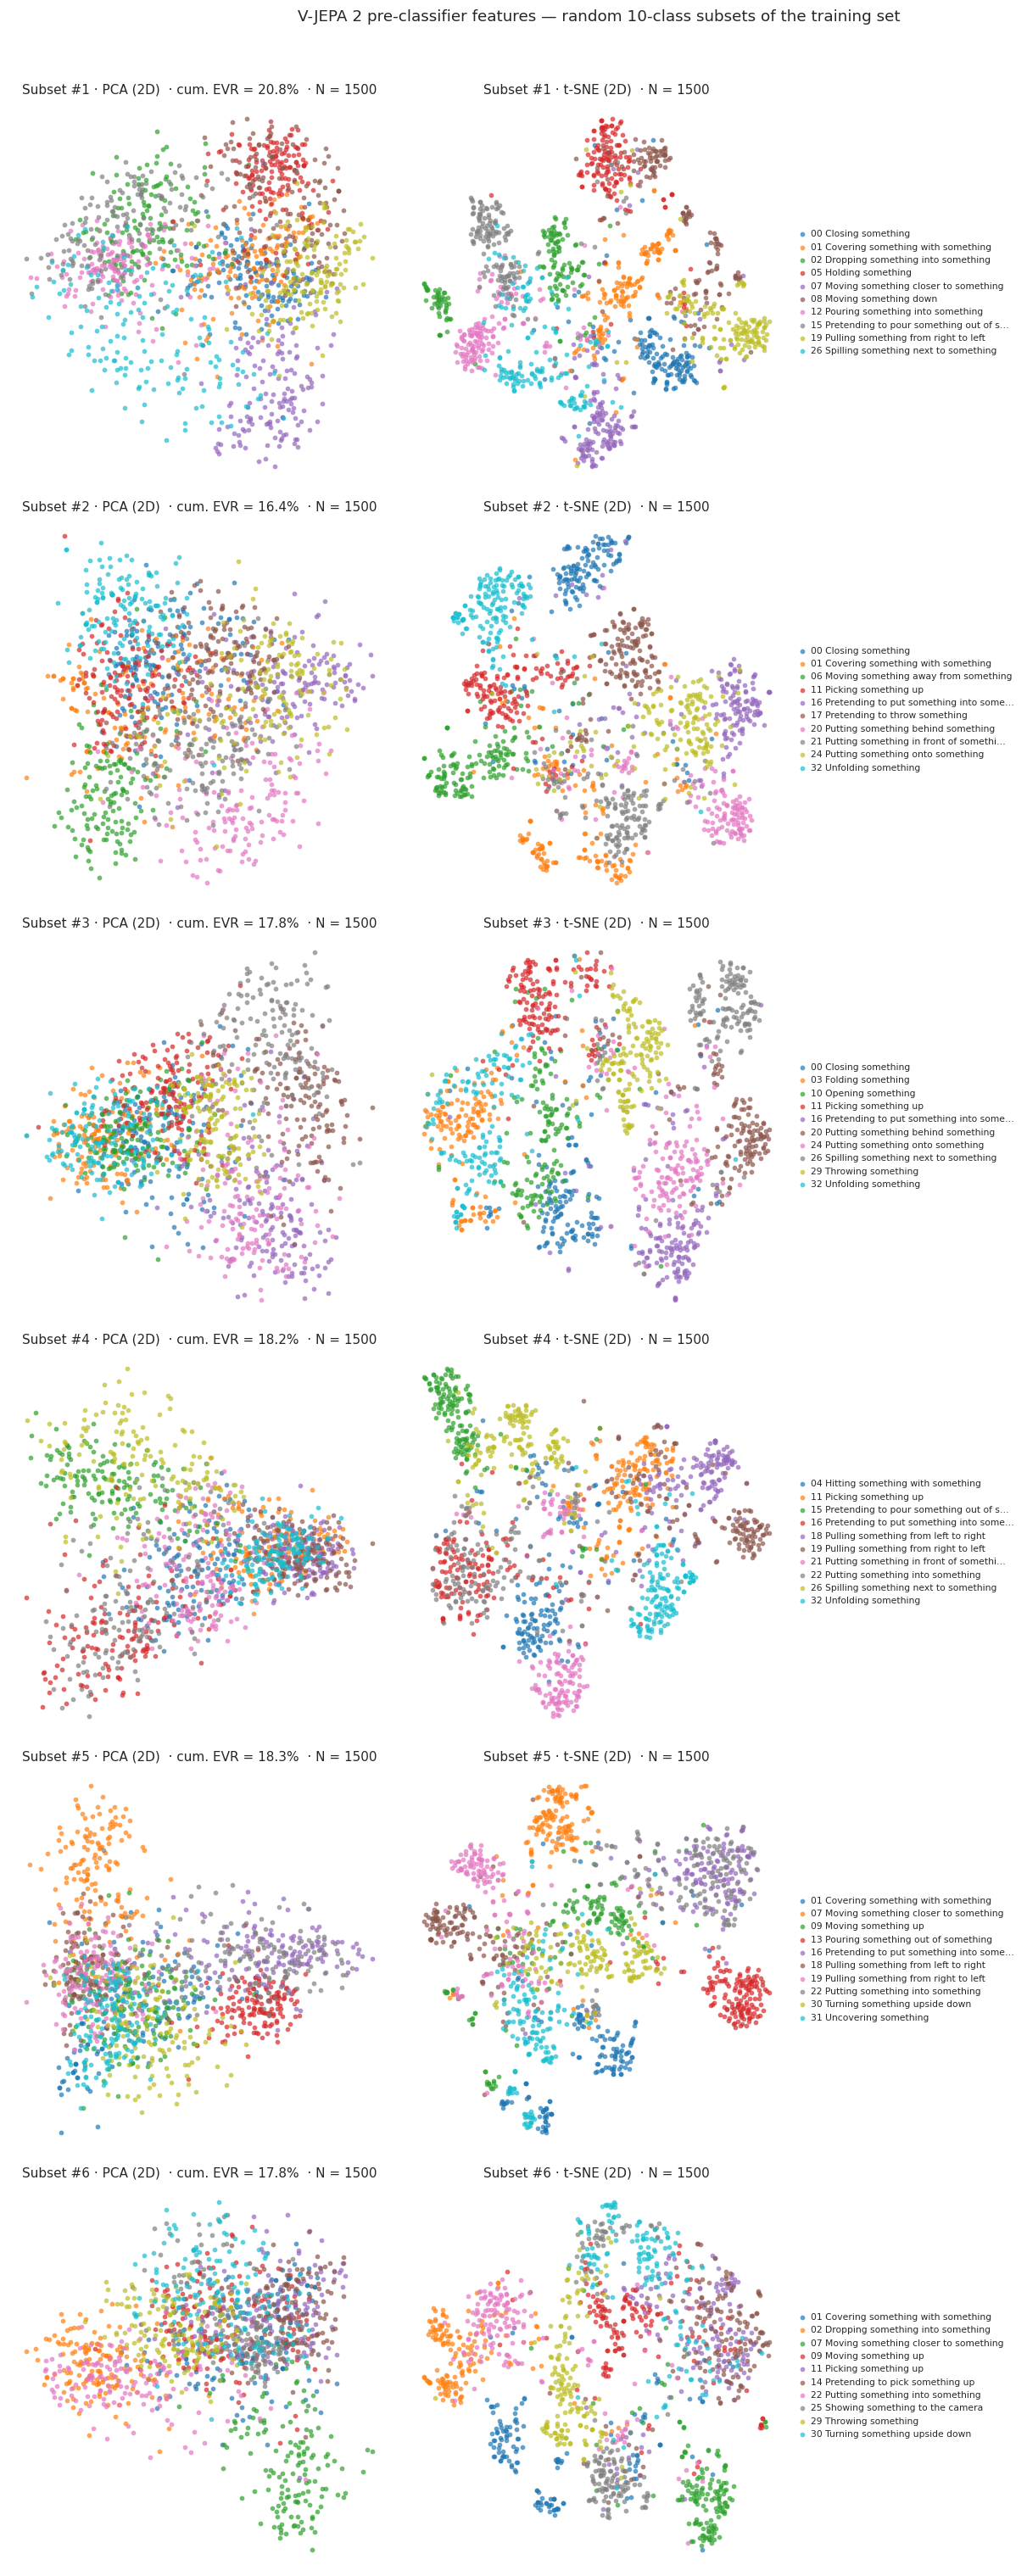

In [6]:
fig, subsets = plot_random_subsets(
    features=features,
    labels=labels,
    class_names=class_names,
    num_subsets=NUM_RANDOM_SUBSETS,
    classes_per_subset=CLASSES_PER_SUBSET,
    master_seed=MASTER_SEED,
)
out_path = FIG_DIR / "vjepa2_pca_tsne_random_subsets.png"
fig.savefig(out_path, bbox_inches="tight", dpi=150)
print(f"saved: {out_path}")
for i, classes in enumerate(subsets, start=1):
    print(f"  subset {i}: {classes}")
plt.show()

## 3. Reference: all 32 classes at once

Reading the 6 random panels in isolation can be misleading because the
*colours are reused across panels*. The plot below shows every class
simultaneously, so we can spot the global structure (and confirm that
what looks like a tight cluster in a 10-class panel is not just an
artifact of leaving 22 other classes out).

saved: /Data/romain.poggi/Modal/project/smth2smth/notebooks/figures/vjepa2_pca_tsne_all_classes.png


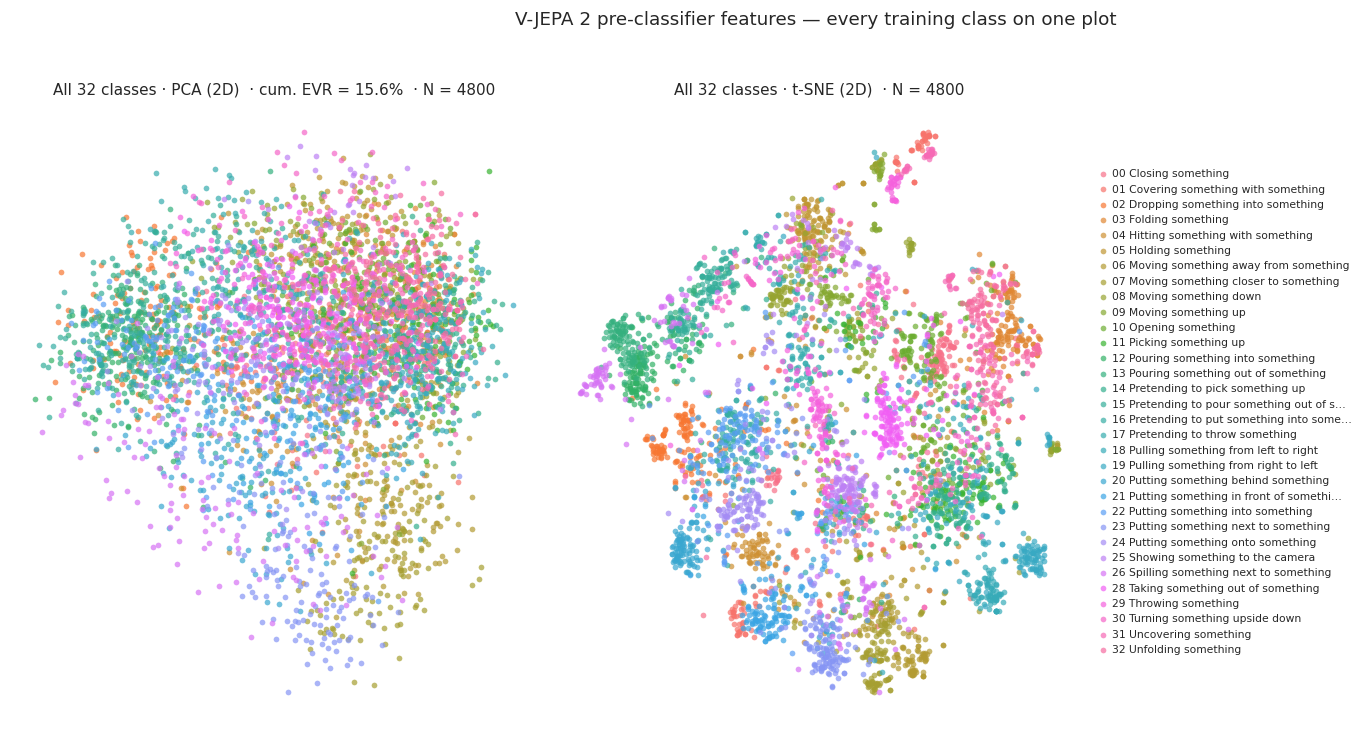

In [7]:
names_by_id = _build_names_by_id(class_names)
all_classes = sorted({int(c) for c in labels})
palette_all = list(sns.color_palette("husl", n_colors=len(all_classes)))
coords_pca_all, coords_tsne_all, labels_all, pca_all, _ = _project_subset(
    features=features,
    labels=labels,
    selected_class_ids=all_classes,
    tsne_seed=MASTER_SEED,
)
evr_all = float(pca_all.explained_variance_ratio_.sum())
fig2, axes2 = plt.subplots(1, 2, figsize=(15.0, 6.5))
_draw_panel(
    axes2[0],
    coords_pca_all,
    labels_all,
    all_classes,
    names_by_id,
    palette=palette_all,
    title=f"All {len(all_classes)} classes \u00b7 PCA (2D)  \u00b7 cum. EVR = {evr_all * 100:.1f}%  \u00b7 N = {labels_all.size}",
    show_legend=False,
)
_draw_panel(
    axes2[1],
    coords_tsne_all,
    labels_all,
    all_classes,
    names_by_id,
    palette=palette_all,
    title=f"All {len(all_classes)} classes \u00b7 t-SNE (2D)  \u00b7 N = {labels_all.size}",
    show_legend=True,
)
fig2.suptitle(
    "V-JEPA 2 pre-classifier features \u2014 every training class on one plot",
    fontsize=12,
    y=1.02,
)
fig2.tight_layout(rect=(0.0, 0.0, 0.84, 1.0))
out_path2 = FIG_DIR / "vjepa2_pca_tsne_all_classes.png"
fig2.savefig(out_path2, bbox_inches="tight", dpi=150)
print(f"saved: {out_path2}")
plt.show()

## 4. Reading the plots

* **PCA captures 2 leading axes** of the standardised 1024-d feature
  cloud. The cumulative explained-variance ratio in each panel title
  tells us how much spread we keep (typically 10–20 % on 10-class
  subsets). Even at that level, related classes (e.g. *moving up* vs.
  *moving down*, *pouring into* vs. *pouring out of*) sit on opposite
  sides of one axis, which is encouraging.
* **t-SNE reveals cluster structure** that the linear projection misses.
  Well-separated, dense blobs predict that a *linear* probe on the
  frozen features can already do the job; classes whose blobs sit on top
  of each other are the ones that drag the Top-1 of the zero-shot
  evaluation down (e.g. *closing* vs. *opening*, where motion direction
  is the only cue and the V-JEPA encoder treats the 16-frame clip as
  near-static for our 4-frame source).
* These plots are evidence that we should be able to push past 50 % with
  even a thin probe on top of the frozen V-JEPA 2 features: the classes
  are visually separable in 2D before we have trained anything.